In [1]:
%load_ext autoreload
%autoreload 2
import sys
import os
ProjDIR = "/home/jw3514/Work/CellType_Psy/CellTypeBias_VIP/" # Change to your project directory
sys.path.insert(1, f'{ProjDIR}/src/')
sys.path.insert(1, '/home/jw3514/Work/UNIMED/src')
from CellType_PSY import *
from UNIMED import *
#import scanpy as sc
HGNC, ENSID2Entrez, GeneSymbol2Entrez, Entrez2Symbol = LoadGeneINFO()

try:
    os.chdir(f"{ProjDIR}/notebooks/")
    print(f"Current working directory: {os.getcwd()}")
except FileNotFoundError as e:
    print(f"Error: Could not change directory - {e}")
except Exception as e:
    print(f"Unexpected error: {e}")

Current working directory: /home/jw3514/Work/CellType_Psy/CellTypeBias_VIP/notebooks


### Read Matrices and annotation

In [2]:
HumanCT_Z2_HCT = pd.read_csv("/home/jw3514/Work/CellType_Psy/dat/HumanCTExpressionMats/HumanCT.Subcluster.TPM.0.1.Filt.Spec.clip.lowexp.cut1e4.csv", index_col=0)
HumanCT_Z2_HCT.shape

(16055, 3313)

In [9]:
Subcluster_anno = pd.read_excel("/home/jw3514/Work/CellType_Psy/dat/subcluster_annotation.xlsx",
                               index_col="Subcluster")

In [10]:
Subcluster_anno.head(3)

,Cluster,Supercluster,Transferred MTG Label (Transferred from cluster level),Class,Neurotransmitter,Neuropeptide,Top ROIGroupFine,Top ROI,Top enriched genes,Number of cells,Number of donors,DoubletFinderScore,TotalUMI,unspliced_ratio,MT_ratio,H18.30.001,H18.30.002,H19.30.001,H19.30.002,Fraction cells from top donor
Subcluster,,,,,,,,,,,,,,,,,,,,
0,297,Upper rhombic lip,NaN,NaN,NT-VGLUT1,NP-CHGA NP-CHGB NP-GRP NP-NUCB NP-NUCB NP-NXPH...,"Midbrain: 97.1%, Thalamus: 2.9%","SC: 73.5%, SN: 20.6%, PAG: 2.9%",['TPH1' 'RBP3' 'AC004852.2' 'GABRR3' 'AQP3' 'N...,34,2,0.012989,7235.000000,0.625557,0.009278,0,8,0,26,26
1,308,Upper rhombic lip,NaN,NaN,NT-VGLUT1,NP-ADCYAP NP-AGT NP-CBLN NP-CHGA NP-CHGB NP-NA...,"Cerebellum: 91.8%, Pons: 7.7%, Myelencephalon:...","CBV: 88.6%, PnAN: 6.8%, CBL: 2.3%",['AC017037.5' 'AC084740.1' 'EOMES' 'LMX1A' 'CS...,220,3,0.104209,11801.659091,0.680623,0.006574,0,75,103,42,103
2,308,Upper rhombic lip,NaN,NaN,NT-VGLUT1,NP-ADCYAP NP-AGT NP-CBLN NP-CHGA NP-CHGB NP-NA...,"Cerebellum: 89.3%, Myelencephalon: 5.9%, Pons:...","CBV: 85.6%, PnAN: 4.3%, MoSR: 3.2%",['AC017037.5' 'AC084740.1' 'EOMES' 'LMX1A' 'CS...,187,3,0.118181,14551.914439,0.686076,0.007234,0,59,89,39,89


In [19]:
Subcluster_anno.loc[1971, :]

Cluster                                                                                                 403
Supercluster                                                                                       Splatter
Transferred MTG Label (Transferred from cluster level)                                                  NaN
Class                                                                                                  NEUR
Neurotransmitter                                                                            NT-GABA NT-GABA
Neuropeptide                                              NP-CBLN NP-CCK NP-CHGA NP-CHGB NP-GAL NP-NAMPT...
Top ROIGroupFine                                          CerebralCortex: 55.4%, Amygdala: 33.8%, Hypoth...
Top ROI                                                                  AON: 28.4%, Pir: 27.0%, CoA: 17.6%
Top enriched genes                                        ['AC012625.1' 'SALL3' 'COL8A1' 'NFATC1' 'KANK3...
Number of cells             

In [22]:
def AnnotateSubcluster(df, Anno=Subcluster_anno):
    for ID, row in df.iterrows():
        id_ = int(ID.split("-")[0])
        df.loc[ID, "Supercluster"] = Anno.loc[id_, "Supercluster"]
        df.loc[ID, "Cluster"] = Anno.loc[id_, "Cluster"]
        df.loc[ID, "Top ROIGroupFine"] = Anno.loc[id_, "Top ROIGroupFine"]
        df.loc[ID, "Top ROI"] = Anno.loc[id_, "Top ROI"]
        df.loc[ID, "Number of cells"] = Anno.loc[id_, "Number of cells"] #Top three dissections
    return df

In [23]:
GeneWeightDIR = "../dat/GeneWeights/"
Bias_Save_Dir = "/home/jw3514/Work/CellType_Psy/CellTypeBias_VIP/dat/Subcluster_Spec_Bias/"
if not os.path.exists(Bias_Save_Dir): # make dir if not exists
    os.makedirs(Bias_Save_Dir)

In [24]:
HIQ_GW = Fil2Dict("{}/HIQ.top61.nopLI.LGD_Dmis_SameWeight.gw".format(GeneWeightDIR))
LIQ_GW = Fil2Dict("{}/LIQ.top61.nopLI.LGD_Dmis_SameWeight.gw".format(GeneWeightDIR))
print(len(HIQ_GW), len(LIQ_GW))

42 49


In [25]:
HIQ_Subcluster_Bias = HumanCT_AvgZ_Weighted(HumanCT_Z2_HCT, HIQ_GW)
HIQ_Subcluster_Bias = AnnotateSubcluster(HIQ_Subcluster_Bias)
#HIQ_Z2_Bias.to_csv("{}/HCT.ASD61.HIQ.csv".format(Bias_Save_Dir))

LIQ_Subcluster_Bias = HumanCT_AvgZ_Weighted(HumanCT_Z2_HCT, LIQ_GW)
LIQ_Subcluster_Bias = AnnotateSubcluster(LIQ_Subcluster_Bias)
#LIQ_Z2_Bias.to_csv("{}/HCT.ASD61.LIQ.csv".format(Bias_Save_Dir))

In [26]:
LIQ_Subcluster_Bias.head(20)

,EFFECT,Rank,Supercluster,Cluster,Top ROIGroupFine,Top ROI,Number of cells
CellType,,,,,,,
1971-403-Splatter,0.496381,1,Splatter,403.0,"CerebralCortex: 55.4%, Amygdala: 33.8%, Hypoth...","AON: 28.4%, Pir: 27.0%, CoA: 17.6%",74.0
2256-191-Hippocampal CA4,0.477648,2,Hippocampal CA4,191.0,"Hippocampus: 97.9%, Midbrain: 2.1%","CA3R: 89.6%, DGU-CA4Upy: 4.2%, SN: 2.1%",48.0
1964-403-Splatter,0.458616,3,Splatter,403.0,"CerebralCortex: 52.1%, Amygdala: 30.0%, Hypoth...","AON: 28.9%, CoA: 27.9%, Pir: 20.5%",190.0
1944-406-Amygdala excitatory,0.439946,4,Amygdala excitatory,406.0,"CerebralCortex: 74.6%, Amygdala: 22.8%, Hypoth...","Pir: 73.7%, CoA: 16.8%, CMN: 5.2%",232.0
2105-220-Medium spiny neuron,0.436562,5,Medium spiny neuron,220.0,"Amygdala: 78.4%, Thalamus: 21.6%","CEN: 76.5%, VA: 17.6%, ANC: 3.9%",51.0
2127-217-Medium spiny neuron,0.423781,6,Medium spiny neuron,217.0,"Amygdala: 92.7%, Thalamus: 4.3%, Hippocampus: ...","CEN: 72.2%, BNST: 11.9%, La: 8.3%",1020.0
1965-403-Splatter,0.420987,7,Splatter,403.0,"CerebralCortex: 52.0%, Amygdala: 30.5%, Hypoth...","AON: 28.2%, CoA: 21.5%, Pir: 18.6%",177.0
3299-1-Miscellaneous,0.420813,8,Miscellaneous,1.0,"Thalamus: 25.7%, Hypothalamus: 22.9%, Cerebral...","HTHtub: 20.0%, ANC: 8.6%, CA1R-CA2R-CA3R: 8.6%",35.0
2743-136-Deep-layer intratelencephalic,0.419374,9,Deep-layer intratelencephalic,136.0,"Amygdala: 81.1%, CerebralCortex: 10.8%, Hypoth...","CoA: 81.1%, AON: 8.1%, HTHso: 5.4%",37.0


In [30]:
def plot_supercluster_bias(df, effect_col="EFFECT", supercluster_col="Supercluster", figsize=(12,6), title="Distribution of Bias (EFFECT) by Supercluster"):
    """
    Plots the distribution of bias (EFFECT) by supercluster as a boxplot.

    Parameters:
        df (pd.DataFrame): DataFrame containing the data.
        effect_col (str): Name of the column containing the effect/bias values.
        supercluster_col (str): Name of the column containing the supercluster labels.
        figsize (tuple): Figure size for the plot.
        title (str): Title for the plot.
    """
    # Sort Superclusters by median EFFECT
    supercluster_order = (
        df.groupby(supercluster_col)[effect_col]
        .median()
        .sort_values(ascending=False)
        .index
    )

    plt.figure(figsize=figsize)
    sns.boxplot(
        data=df,
        x=supercluster_col,
        y=effect_col,
        order=supercluster_order
    )
    plt.xticks(rotation=45, ha='right')
    plt.title(title)
    plt.ylabel(f"Bias ({effect_col})")
    plt.xlabel(supercluster_col)
    plt.tight_layout()
    plt.show()

# Example usage:
# plot_supercluster_bias(LIQ_Subcluster_Bias)

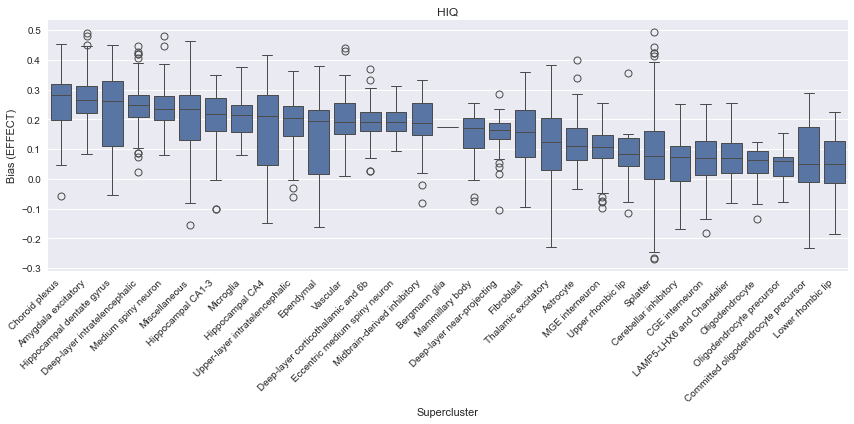

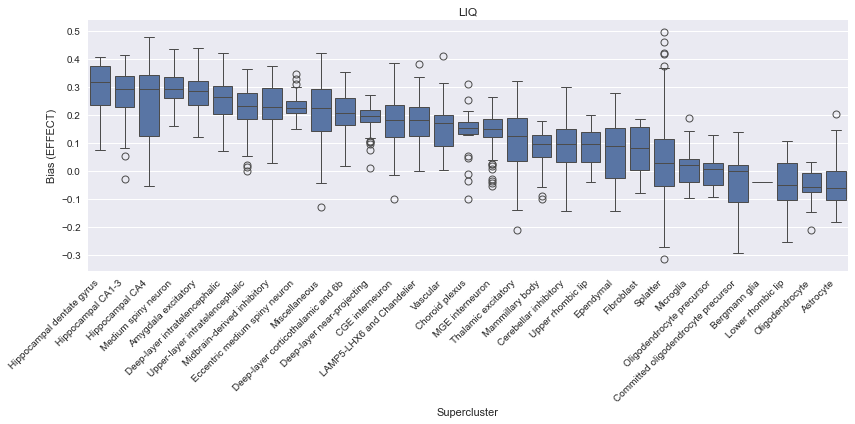

In [32]:
plot_supercluster_bias(HIQ_Subcluster_Bias, title="HIQ")
plot_supercluster_bias(LIQ_Subcluster_Bias, title="LIQ")

# PBS with subcluster

In [41]:
Mut_n_IQ_conf = pd.read_csv("/home/jw3514/Work/CellType_Psy/CellTypeBias_VIP/dat/Pheno_Bias_vs_IQ/Mut_n_IQ_conf.csv", index_col=0)
Avg_Gene_IQ_DF = pd.read_csv("/home/jw3514/Work/CellType_Psy/CellTypeBias_VIP/dat/Pheno_Bias_vs_IQ/Mut_n_IQ_conf.GeneL.csv", index_col=0)
Mut_n_IQ_conf.head(2)
Avg_Gene_IQ_DF.head(2)

,Entrez,IQ
0,23040,59.000000
1,6529,50.857143


In [50]:
def linear_fit(biases, IQs, alpha=0.05):
    model = sm.OLS(IQs, sm.add_constant(biases))
    results = model.fit()
    
    intercept = results.params[0]
    beta = results.params[1]
    # get CI of beta
    ci = results.conf_int(alpha=alpha)

    ci_low = ci[1][0]
    ci_high = ci[1][1]     
    r_value = results.rsquared
    p_value = results.pvalues[1]
    std_err = results.bse[1]
    rho, p_rho = spearmanr(biases, IQs)
    r, p_r = pearsonr(biases, IQs)
    
    return intercept, beta, ci_low, ci_high, r_value, p_value, std_err, rho, p_rho, r, p_r

def Make_HumanCT_DF(Mut_n_IQ_conf, HCT_Z2_MAT_HCT, Anno, output_file, alpha=0.05):
    names, cluster, supercluster, spearmanr, spearmanp, pearsonr, pearsonp, beta_values, beta_ci_low, beta_ci_high, intercept_values, r_value_values, p_value_values, std_err_values = [], [],[],[],[],[],[],[],[],[],[],[],[],[]
    for i, Idx in enumerate(HCT_Z2_MAT_HCT.columns.values):
        biases, IQs = BiasVsPheno(Mut_n_IQ_conf, HCT_Z2_MAT_HCT , Idx, 'xx')
        intercept, beta, ci_low, ci_high, r_value, p_value, std_err, rho, p_rho, r, p_r = linear_fit(biases, IQs, alpha=0.05)
        
        names.append("{}".format(Idx))

        cluster.append(Anno.loc[i, "Cluster"])
        supercluster.append(Anno.loc[i, "Supercluster"])
        spearmanr.append(rho)
        spearmanp.append(p_rho)
        pearsonr.append(r)
        pearsonp.append(p_r)
        beta_values.append(beta)
        beta_ci_low.append(ci_low)
        beta_ci_high.append(ci_high)
        intercept_values.append(intercept)
        r_value_values.append(r_value)
        p_value_values.append(p_value)
        std_err_values.append(std_err)

    str_res_df = pd.DataFrame(data={"CT":names, "Cluster":cluster, "Supercluster":supercluster, "SpearmanR":spearmanr, "SpearmanP":spearmanp, 
                                            "PearsonR":pearsonr, "PearsonP":pearsonp, "beta":beta_values, "CI_low":beta_ci_low, "CI_high":beta_ci_high, "intercept":intercept_values, "r_value":r_value_values, 
                                            "p_value":p_value_values, "std_err":std_err_values})
    str_res_df = str_res_df.sort_values("SpearmanR")
    #str_res_df = ADJ_P(str_res_df)
    str_res_df.to_csv(output_file)
    return str_res_df

In [51]:
HumanCT_res_df_GeneL = Make_HumanCT_DF(Avg_Gene_IQ_DF, HumanCT_Z2_HCT, Subcluster_anno, "../dat/Pheno_Bias_vs_IQ/HumanCT.Subclusterspec.GeneL.csv")

In [ ]:
HumanCT_res_df_GeneL = 

In [52]:
HumanCT_res_df_GeneL.head(20)

,CT,Cluster,Supercluster,SpearmanR,SpearmanP,PearsonR,PearsonP,beta,CI_low,CI_high,intercept,r_value,p_value,std_err
473,473-267-LAMP5-LHX6 and Chandelier,267,LAMP5-LHX6 and Chandelier,-0.509349,0.000061,-0.459233,0.000371,-17.623817,-26.924735,-8.322900,63.365520,0.210895,0.000371,4.639141
381,381-266-LAMP5-LHX6 and Chandelier,266,LAMP5-LHX6 and Chandelier,-0.505836,0.000070,-0.448301,0.000530,-18.613223,-28.738897,-8.487550,65.599712,0.200974,0.000530,5.050515
467,467-269-LAMP5-LHX6 and Chandelier,269,LAMP5-LHX6 and Chandelier,-0.502307,0.000080,-0.458283,0.000383,-18.526797,-28.329924,-8.723669,66.369304,0.210024,0.000383,4.889635
382,382-265-LAMP5-LHX6 and Chandelier,265,LAMP5-LHX6 and Chandelier,-0.482765,0.000164,-0.355758,0.007127,-14.209225,-24.393322,-4.025127,64.844210,0.126564,0.007127,5.079656
624,624-276-CGE interneuron,276,CGE interneuron,-0.476860,0.000203,-0.447044,0.000552,-15.698017,-24.267832,-7.128202,67.117343,0.199849,0.000552,4.274479
459,459-268-LAMP5-LHX6 and Chandelier,268,LAMP5-LHX6 and Chandelier,-0.464980,0.000306,-0.430701,0.000921,-16.498885,-25.931115,-7.066655,65.454432,0.185504,0.000921,4.704637
460,460-268-LAMP5-LHX6 and Chandelier,268,LAMP5-LHX6 and Chandelier,-0.464546,0.000310,-0.401537,0.002160,-16.001051,-25.958190,-6.043912,64.923083,0.161232,0.002160,4.966453
385,385-266-LAMP5-LHX6 and Chandelier,266,LAMP5-LHX6 and Chandelier,-0.450863,0.000488,-0.350191,0.008149,-14.057733,-24.316424,-3.799042,63.990255,0.122634,0.008149,5.116862
384,384-266-LAMP5-LHX6 and Chandelier,266,LAMP5-LHX6 and Chandelier,-0.450259,0.000498,-0.372307,0.004719,-15.100934,-25.371482,-4.830387,64.948872,0.138612,0.004719,5.122776
476,476-267-LAMP5-LHX6 and Chandelier,267,LAMP5-LHX6 and Chandelier,-0.440210,0.000686,-0.422885,0.001166,-17.315224,-27.438310,-7.192139,64.468467,0.178832,0.001166,5.049225


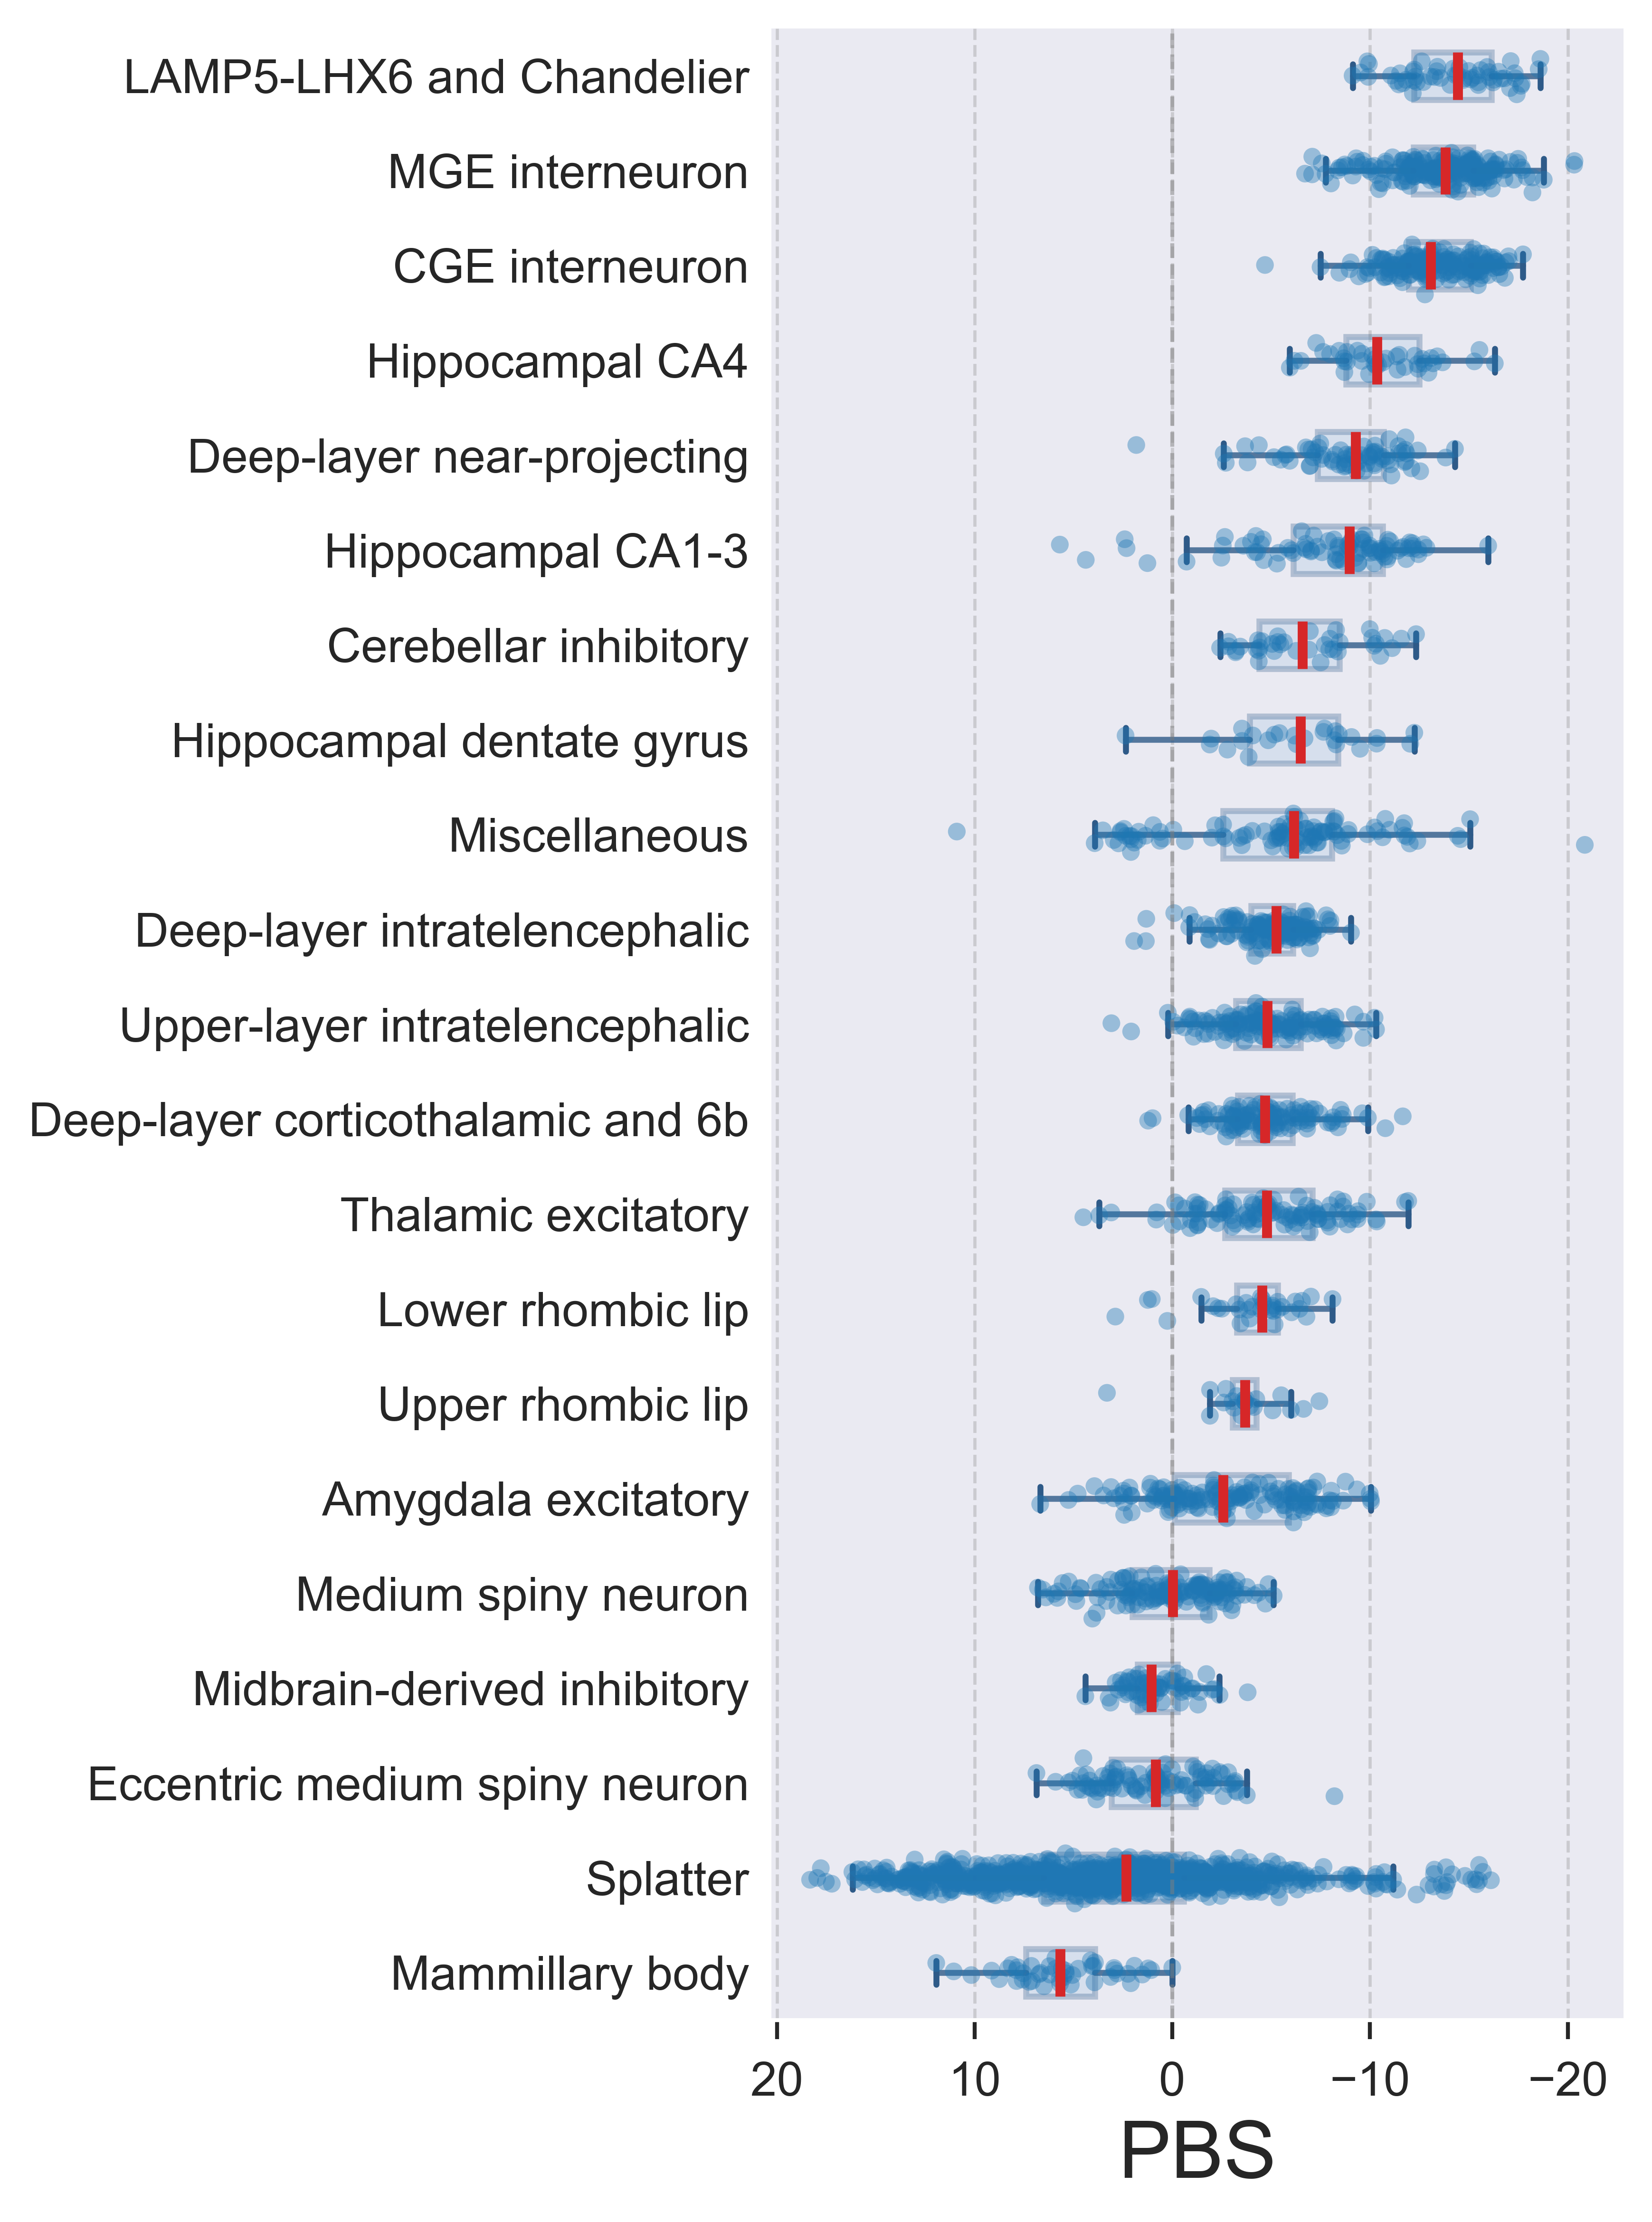

In [56]:
SuperClusterBias_BoxPlot_CorrIQ(HumanCT_res_df_GeneL, flip_axis=True, figsize=(6, 8), plot_metric="beta")

In [57]:
TPM = pd.read_csv("/home/jw3514/Work/CellType_Psy/dat/HumanCTExpressionMats/HumanCT.Subcluster.TPM.0.1.Filt.csv", index_col=0)

In [59]:
TPM.head(2)

,0-297-Upper rhombic lip,1-308-Upper rhombic lip,2-308-Upper rhombic lip,3-308-Upper rhombic lip,4-308-Upper rhombic lip,5-308-Upper rhombic lip,6-309-Upper rhombic lip,7-309-Upper rhombic lip,8-309-Upper rhombic lip,9-310-Upper rhombic lip,...,3303-1-Miscellaneous,3304-1-Miscellaneous,3305-1-Miscellaneous,3306-1-Miscellaneous,3307-2-Miscellaneous,3308-2-Miscellaneous,3309-2-Miscellaneous,3310-2-Miscellaneous,3311-2-Miscellaneous,3312-2-Miscellaneous
1,3.281188,4.237787,2.551057,6.091291,4.728634,11.723644,6.707472,7.221692,23.462897,7.266220,...,15.867473,6.942650,16.091636,8.212071,2.439455,8.766673,15.411167,20.077350,8.215469,15.359936
2,0.000000,8.341218,6.829818,8.962850,7.768014,8.734027,6.707472,4.833877,10.319809,6.445245,...,80.917628,301.204088,377.572212,265.699947,51.008867,29.207377,45.478022,70.781332,142.662385,91.351800


In [60]:
HumanCT_res_df_GeneL.head(2)

,CT,Cluster,Supercluster,SpearmanR,SpearmanP,PearsonR,PearsonP,beta,CI_low,CI_high,intercept,r_value,p_value,std_err
473,473-267-LAMP5-LHX6 and Chandelier,267,LAMP5-LHX6 and Chandelier,-0.509349,0.000061,-0.459233,0.000371,-17.623817,-26.924735,-8.32290,63.365520,0.210895,0.000371,4.639141
381,381-266-LAMP5-LHX6 and Chandelier,266,LAMP5-LHX6 and Chandelier,-0.505836,0.000070,-0.448301,0.000530,-18.613223,-28.738897,-8.48755,65.599712,0.200974,0.000530,5.050515


In [61]:
PBS_CGE = HumanCT_res_df_GeneL[HumanCT_res_df_GeneL["Supercluster"]=="CGE interneuron"].copy()
PBS_CGE = PBS_CGE.set_index("CT")
PBS_CGE["VIP_ExpL"] = TPM.loc[GeneSymbol2Entrez["VIP"], PBS_CGE.index]

In [62]:
PBS_CGE

,Cluster,Supercluster,SpearmanR,SpearmanP,PearsonR,PearsonP,beta,CI_low,CI_high,intercept,r_value,p_value,std_err,VIP_ExpL
CT,,,,,,,,,,,,,,
624-276-CGE interneuron,276,CGE interneuron,-0.476860,0.000203,-0.447044,0.000552,-15.698017,-24.267832,-7.128202,67.117343,0.199849,0.000552,4.274479,573.606492
482-276-CGE interneuron,276,CGE interneuron,-0.439954,0.000692,-0.456565,0.000405,-17.732205,-27.159573,-8.304837,65.846764,0.208451,0.000405,4.702212,578.607891
509-294-CGE interneuron,294,CGE interneuron,-0.437112,0.000756,-0.397490,0.002417,-16.537709,-26.953624,-6.121794,65.400635,0.157998,0.002417,5.195283,1424.723342
599-294-CGE interneuron,294,CGE interneuron,-0.423268,0.001153,-0.385760,0.003322,-16.496591,-27.260778,-5.732404,66.423971,0.148811,0.003322,5.368995,613.012195
621-294-CGE interneuron,294,CGE interneuron,-0.419346,0.001295,-0.431744,0.000892,-16.485764,-25.882538,-7.088990,66.376338,0.186403,0.000892,4.686952,2204.510478
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
560-283-CGE interneuron,283,CGE interneuron,-0.107532,0.430208,-0.224984,0.095495,-8.958808,-19.544307,1.626690,64.212905,0.050618,0.095495,5.279868,4.938624
431-287-CGE interneuron,287,CGE interneuron,-0.105923,0.437177,-0.252024,0.060957,-10.312908,-21.116827,0.491011,64.235022,0.063516,0.060957,5.388813,0.979154
531-291-CGE interneuron,291,CGE interneuron,-0.087643,0.520674,-0.263819,0.049452,-10.990131,-21.952949,-0.027314,63.303947,0.069601,0.049452,5.468069,162.735386


(array([11., 19., 17., 12.,  7., 15., 30., 25., 30., 14.]),
 array([-0.40109648,  0.01385712,  0.42881071,  0.84376431,  1.2587179 ,
         1.6736715 ,  2.08862509,  2.50357869,  2.91853228,  3.33348588,
         3.74843947]),
 <BarContainer object of 10 artists>)

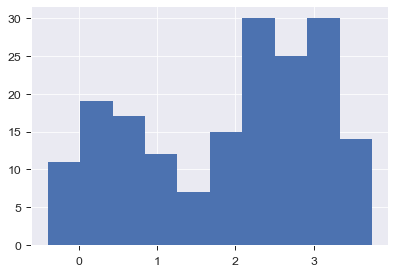

In [65]:
#PBS_CGE["VIP_ExpL"].hist()
plt.hist(np.log10(PBS_CGE["VIP_ExpL"]))

In [66]:
VIP_Cutoff = 100
VIP_Pos = PBS_CGE[PBS_CGE["VIP_ExpL"] > VIP_Cutoff]
VIP_Neg = PBS_CGE[PBS_CGE["VIP_ExpL"] < VIP_Cutoff]

/tmp/ipykernel_573837/350067024.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(data, labels=["VIP+", "VIP-"])


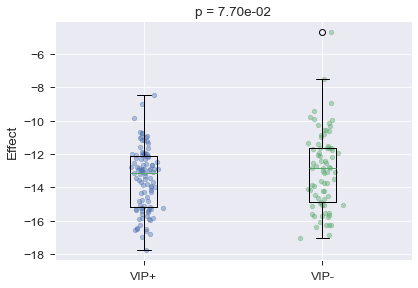

In [69]:
data = [VIP_Pos["beta"], VIP_Neg["beta"]]
# Perform Mann-Whitney U test
stat, pval = scipy.stats.mannwhitneyu(VIP_Pos["beta"], 
                                    VIP_Neg["beta"], alternative="less")
# Create boxplot with individual points
bp = plt.boxplot(data, labels=["VIP+", "VIP-"])
# Add scatter points
for i, d in enumerate([VIP_Pos["beta"], VIP_Neg["beta"]]):
    x = np.random.normal(i+1, 0.04, size=len(d))
    plt.scatter(x, d, alpha=0.4, s=20)
plt.ylabel("Effect")
plt.title(f"p = {pval:.2e}")
plt.show()